In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

In [2]:
!pip install tensorflow

In [3]:
!pip install -U tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.1 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is in

In [59]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [60]:
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_PATH = '/content/biodeg_cleaned.xlsx'
TEST_SIZE = 0.20
N_SPLITS = 5

# upload data
df = pd.read_excel(DATA_PATH, engine='openpyxl')

# target and features
assert 'Class' in df.columns, "No Class Column"
y = df['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
X = df.drop(columns=['Class'])

In [61]:
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
1050,1
1051,1
1052,1
1053,1


In [62]:
X

,SpMax_L,nHM,F01[N-N],nCb,C%,nO,F03[C-N],F03[C-O],Me,Mi,nArNO2,nCIR,B01[C-Br],B03[C-Cl],SpMax_A,nHDon,nN,nArCOOR,nX
0,3.919,0,0,0,31.4,0,0,0,0.960,1.142,0,0,0,0,1.932,0,0,0,0
1,4.170,0,0,0,30.8,1,0,1,0.989,1.144,0,1,0,0,2.214,0,0,0,0
2,3.932,0,0,0,26.7,4,0,0,1.009,1.152,0,0,0,0,1.942,1,0,0,0
3,3.000,0,0,0,20.0,2,0,0,1.108,1.167,0,0,0,0,1.414,1,0,0,0
4,4.236,0,0,0,29.4,4,0,2,1.004,1.147,0,0,0,0,1.985,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,5.431,0,0,0,32.1,1,1,2,0.982,1.144,0,1,0,0,2.394,1,1,0,0
1051,5.287,0,0,0,35.3,9,9,21,1.043,1.140,0,1,0,0,2.462,0,3,0,0
1052,4.869,0,1,5,44.4,4,14,9,1.016,1.123,1,3,0,0,2.314,0,5,1,0
1053,5.158,2,0,9,56.1,0,44,0,1.007,1.093,0,147,0,1,2.622,0,8,0,1


In [63]:
# Feature engineering
count_cols = ['nHM', 'nO', 'nN', 'nArNO2', 'nCIR']
for c in count_cols:
    if c in X.columns:
        X[f'log_{c}'] = np.log1p(X[c])  # ln(x+1)

# rates
if 'nN' in X.columns and 'nO' in X.columns:
    X['N_to_O_Ratio'] = X['nN'] / (X['nO'] + 1)

In [64]:
# intensity of halojen
br_col = None
cl_col = None
for col in X.columns:
    if 'C-Br' in col and 'B01' in col: br_col = col
    if 'C-Cl' in col and 'B03' in col: cl_col = col
if br_col and cl_col and ('nHM' in X.columns):
    X['Halo_Density'] = (X[br_col] + X[cl_col]) / (X['nHM'] + 1)

# Spektral indeks interaction
if 'SpMax_L' in X.columns and {'nN','nO','nArNO2'}.issubset(X.columns):
    X['Index_Interaction'] = X['SpMax_L'] * (X['nN'] + X['nO'] + X['nArNO2'])

In [65]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [66]:
# 7) NN structure
def build_model(input_dim, config):
    """model = keras.Sequential(name=config.get('name', 'NN'))
    # Hidden layers
    for i, (units, dropout) in enumerate(zip(config['units'], config['dropout'])):
        if i == 0:
            model.add(layers.Dense(units, activation=config.get('activation','relu'),
                                   input_dim=input_dim))
        else:
            model.add(layers.Dense(units, activation=config.get('activation','relu')))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    # output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    # Optimizasyon
    opt = keras.optimizers.Adam(learning_rate=config.get('lr', 1e-3))
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model"""

    """
    UYARI YOK: İlk katmanda input_dim vermek yerine ayrı Input(...) kullanıyoruz.
    """
    model = keras.Sequential(name=cfg.get('name', 'NN'))
    # Keras 3 tavsiyesi: ayrı Input katmanı
    model.add(keras.Input(shape=(input_dim,), name="model_input"))
    for units, dropout in zip(cfg['units'], cfg['dropout']):
        model.add(layers.Dense(units, activation=cfg.get('activation', 'relu')))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    opt = keras.optimizers.Adam(learning_rate=cfg.get('lr', 1e-3))
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [67]:
# NN achitectures which will be tried
candidates = [
    {'name':'NN_32x2_dp0.2',       'units':[32, 32],     'dropout':[0.2, 0.2],     'lr':1e-3},
    {'name':'NN_64-32-16_dp0.3',   'units':[64, 32, 16], 'dropout':[0.3, 0.3, 0.3],'lr':1e-3},
    {'name':'NN_128-64_dp0.5',     'units':[128, 64],    'dropout':[0.5, 0.5],     'lr':5e-4},
    {'name':'NN_64x3_dp0.2',       'units':[64, 64, 64], 'dropout':[0.2, 0.2, 0.2],'lr':1e-3},
]

# 5-fold stratified CV function
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


In [68]:
def cross_val_score_nn(X_scaled, y, config):
    accs = []
    cw = class_weight.compute_class_weight(class_weight='balanced',
                                           classes=np.array([0,1]),
                                           y=y)
    cw_dict = {0: cw[0], 1: cw[1]}
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_scaled, y), start=1):
        X_tr, X_val = X_scaled[tr_idx], X_scaled[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = build_model(X_scaled.shape[1], config)
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                           restore_best_weights=True)
        # trsin
        history = model.fit(
            X_tr, y_tr,
            epochs=200, batch_size=32,
            validation_data=(X_val, y_val),
            callbacks=[es],
            verbose=0,
            class_weight=cw_dict
        )
        # Evaluate
        y_val_pred = (model.predict(X_val, verbose=0).ravel() >= 0.5).astype(int)
        acc = accuracy_score(y_val, y_val_pred)
        accs.append(acc)

        # clear the resources
        tf.keras.backend.clear_session()
    return float(np.mean(accs)), float(np.std(accs))

In [69]:
# 10) evaluate the sarchitectures, and choose the best 3
results = []
for cfg in candidates:
    mean_acc, std_acc = cross_val_score_nn(X_train_scaled, y_train, cfg)
    results.append({'Model':cfg['name'], 'CV_mean_acc':mean_acc, 'CV_std_acc':std_acc})

res_df = pd.DataFrame(results).sort_values('CV_mean_acc', ascending=False)
print("\n=== 5-Fold CV Results (Train/Val) ===")
print(res_df)


=== 5-Fold CV Results (Train/Val) ===
               Model  CV_mean_acc  CV_std_acc
0      NN_32x2_dp0.2     0.873281    0.029217
3      NN_64x3_dp0.2     0.872084    0.026200
1  NN_64-32-16_dp0.3     0.868533    0.023893
2    NN_128-64_dp0.5     0.860249    0.029665


In [70]:
# Evaluate the best 3 structures on test-set
best3 = res_df.head(3)['Model'].tolist()

def get_cfg_by_name(name):
    return next(c for c in candidates if c['name'] == name)


>>> NN_32x2_dp0.2 – Test Accuracy: 0.8531
              precision    recall  f1-score   support

         NRB       0.79      0.77      0.78        71
          RB       0.89      0.89      0.89       140

    accuracy                           0.85       211
   macro avg       0.84      0.83      0.83       211
weighted avg       0.85      0.85      0.85       211



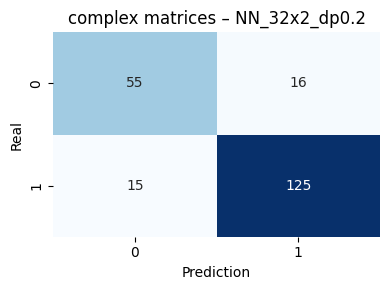


>>> NN_64x3_dp0.2 – Test Accuracy: 0.8436
              precision    recall  f1-score   support

         NRB       0.80      0.72      0.76        71
          RB       0.86      0.91      0.89       140

    accuracy                           0.84       211
   macro avg       0.83      0.81      0.82       211
weighted avg       0.84      0.84      0.84       211



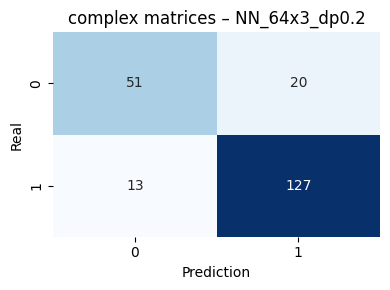


>>> NN_64-32-16_dp0.3 – Test Accuracy: 0.8578
              precision    recall  f1-score   support

         NRB       0.83      0.73      0.78        71
          RB       0.87      0.92      0.90       140

    accuracy                           0.86       211
   macro avg       0.85      0.83      0.84       211
weighted avg       0.86      0.86      0.86       211



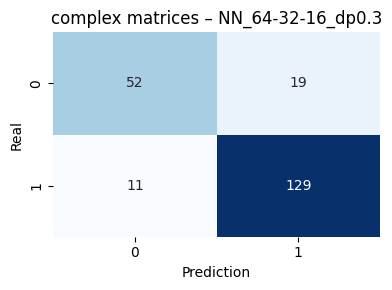

In [71]:
summary_rows = []
for mname in best3:
    cfg = get_cfg_by_name(mname)
    model = build_model(X_train_scaled.shape[1], cfg)
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                       restore_best_weights=True)
    #Train with  Validation split
    history = model.fit(
        X_train_scaled, y_train,
        epochs=300, batch_size=32, validation_split=0.2,
        callbacks=[es], verbose=0
    )

    # Test performance
    y_test_proba = model.predict(X_test_scaled, verbose=0).ravel()
    y_test_pred  = (y_test_proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_test_pred)
    print(f"\n>>> {mname} – Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_test_pred, target_names=['NRB','RB']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'complex matrices – {mname}')
    plt.xlabel('Prediction')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

    summary_rows.append({
        'Model': mname,
        'Test_Accuracy': acc,
        'TP': cm[1,1], 'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0]
    })

In [72]:
# the table that is about the best 3 structure
summary_df = pd.DataFrame(summary_rows)
print("\n=== Task 1 – Sum of the best 3 structure ===")
print(summary_df)


=== Task 1 – Sum of the best 3 structure ===
               Model  Test_Accuracy   TP  TN  FP  FN
0      NN_32x2_dp0.2       0.853081  125  55  16  15
1      NN_64x3_dp0.2       0.843602  127  51  20  13
2  NN_64-32-16_dp0.3       0.857820  129  52  19  11


In [19]:
!pip install scikeras

In [20]:
!pip -q install catboost scikeras lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [73]:
from scikeras.wrappers import KerasClassifier
from catboost import CatBoostClassifier, Pool
from collections import defaultdict

In [74]:
BASE_RANDOM_STATE = 42
N_SEEDS_DROP = 3
N_SPLITS_PI = 10
N_REPEATS_PI = 10
TEST_SIZE_FALLBACK = 0.20
DEFAULT_EPOCHS = 100
DEFAULT_PATIENCE = 5
DEFAULT_SEEDS = 3

In [75]:
# Normalize
def normalize_importances(d):
    vals = np.array(list(d.values()), dtype=float)
    s = vals.sum()
    if s <= 0:
        vals = np.abs(vals)
        s = vals.sum() if vals.sum() > 0 else 1.0
    vals = vals / s
    return {k: float(v) for k, v in zip(d.keys(), vals)}

In [76]:
# Plot to show
def plot_importance_bar(imp_dict, title):
    items = sorted(imp_dict.items(), key=lambda x: x[1], reverse=True)
    labels, values = zip(*items)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(labels), y=list(values), color='#4c78a8')
    plt.xticks(rotation=75)
    plt.ylabel('Importance (Sum=1)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [77]:

# use the architectural choice again from Task-1
def get_task1_best_cfg_or_fallback():
    """
    The defined best 3 architectures and the candidates list are used(best3[0]), and if not,
    a fallback NN configuration is returned.
    """
    try:
        # from Task-1: candidates & get_cfg_by_name & best3
        assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
        if 'best3' in globals() and len(best3) > 0:
            return get_cfg_by_name(best3[0])
        else:
            # best3 or first good candidate
            return candidates[0]
    except Exception:
        # structure of Fallback
        return {
            'name':'NN_fallback_64-32-16',
            'units':[64, 32, 16],
            'dropout':[0.3, 0.3, 0.3],
            'lr':1e-3,
            'activation':'relu',
            'epochs':100,
            'batch_size':32,
            'patience':6
        }

In [78]:
# Use the build function from Task-1 or create fallback
def ensure_build_fn(input_dim, cfg):
    """
    If a build_model or build_keras_sequential is defined in Task 1, it uses it; otherwise, it creates a sequential model here.
    if the build_model or build_keras_sequential functions are defined in Task-1
    """
    if 'build_model' in globals():
        return build_model(input_dim, cfg)
    elif 'build_keras_sequential' in globals():
        return build_keras_sequential(input_dim, cfg)
    else:
        # Fallback builder
        from tensorflow.keras import layers
        model = keras.Sequential(name=cfg.get('name','NN'))
        for i, (units, dp) in enumerate(zip(cfg['units'], cfg['dropout'])):
            if i == 0:
                model.add(layers.Dense(units, activation=cfg['activation'], input_dim=input_dim))
            else:
                model.add(layers.Dense(units, activation=cfg['activation']))
            if dp and dp > 0:
                model.add(layers.Dropout(dp))
        model.add(layers.Dense(1, activation='sigmoid'))
        opt = keras.optimizers.Adam(learning_rate=cfg['lr'])
        model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        return model


In [79]:

def fit_nn_with_val(X_tr_s, y_tr, X_val_s, y_val, cfg):
    es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                       patience=cfg.get('patience',10),
                                       restore_best_weights=True)
    model = ensure_build_fn(X_tr_s.shape[1], cfg)
    model.fit(X_tr_s, y_tr,
              epochs=cfg.get('epochs',200),
              batch_size=cfg.get('batch_size',32),
              validation_data=(X_val_s, y_val),
              callbacks=[es], verbose=0)
    return model

In [80]:

# --- Task 1’deki veri & split & scaler’ı yeniden kullan ---
def get_task1_data_or_fallback():
    """
    Task 1’den X, y, X_train, X_test, y_train, y_test, scaler değişkenlerini kullanır.
    Yoksa minimum fallback ile aynı isimli değişkenleri üretir.
    """
    # 1) X & y
    if 'X' in globals() and 'y' in globals():
        local_X, local_y = X.copy(), y.copy()
    else:
        # Fallback: dosyadan oku (Task 1'de zaten yüklü olmalıydı)
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        local_y = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        local_X = df_fb.drop(columns=['Class'])

    # 2) Train/Test split
    if all(k in globals() for k in ['X_train','X_test','y_train','y_test']):
        X_tr, X_te = X_train.copy(), X_test.copy()
        y_tr, y_te = y_train.copy(), y_test.copy()
        # Ölçekleyici
        if 'scaler' in globals():
            local_scaler = scaler
        else:
            local_scaler = StandardScaler().fit(X_tr)
    else:
        # Fallback split
        X_tr, X_te, y_tr, y_te = train_test_split(
            local_X, local_y, test_size=TEST_SIZE_FALLBACK,
            stratify=local_y, random_state=BASE_RANDOM_STATE
        )
        local_scaler = StandardScaler().fit(X_tr)

    # 3) Ölçeklenmiş matrisler (Task 1'dekileri tekrar hesaplamıyoruz; yoksa üretiyoruz)
    try:
        X_train_scaled_used = X_train_scaled  # Task 1’den
        X_test_scaled_used  = X_test_scaled
    except Exception:
        X_train_scaled_used = local_scaler.transform(X_tr)
        X_test_scaled_used  = local_scaler.transform(X_te)

    return local_X, local_y, X_tr, X_te, y_tr, y_te, local_scaler, X_train_scaled_used, X_test_scaled_used

In [81]:
def _ensure_float32(X):
    # Keras için float32 önerilir
    if isinstance(X, pd.DataFrame):
        return X.astype(np.float32)
    return np.asarray(X, dtype=np.float32)

In [82]:
def _quick_topk_logreg(X_all, y_all, k):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=TEST_SIZE_FALLBACK,
        stratify=y_all, random_state=BASE_RANDOM_STATE
    )
    sc = StandardScaler().fit(X_tr)
    X_tr_s = sc.transform(X_tr)
    lr = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced',
                            random_state=BASE_RANDOM_STATE)
    lr.fit(X_tr_s, y_tr)
    coefs = np.abs(lr.coef_.ravel())
    order = np.argsort(coefs)[::-1]
    features_sorted = X_tr.columns[order].tolist()
    return features_sorted[:k]

In [83]:
def drop_column_importance_nn_task1_split_topk(top_features=None,
                                               top_k=None,
                                               preselect_method='logreg',
                                               seeds=DEFAULT_SEEDS):

    """
    Aynı train/test split ve aynı baz scaler (Task 1’den) kullanılır.
    10 farklı seed ile NN yeniden eğitilir; her iterasyonda her özelliği düşürerek
    doğruluk farkı (base_acc - drop_acc) önem olarak kaydedilir.
    """

# 1) Veri/split/scaler & cfg
    X_all, y_all, X_tr, X_te, y_tr, y_te, base_scaler, X_tr_s, X_te_s = get_task1_data_or_fallback()
    cfg = get_task1_best_cfg_or_fallback()

    # 2) Top-K setini belirle
    if top_features is not None and len(top_features) > 0:
        features = [f for f in top_features if f in X_all.columns]
    elif isinstance(top_k, int) and top_k > 0:
        if preselect_method == 'logreg':
            features = _quick_topk_logreg(X_all, y_all, top_k)
        else:
            # Gerekirse burada başka hızlı yöntemler eklenebilir (örn. permutation tek split)
            features = _quick_topk_logreg(X_all, y_all, top_k)
    else:
        features = X_all.columns.tolist()  # tüm kolonlar

    # 3) Baz doğruluk (Kısa varsayılanlarla)
    tf.keras.backend.clear_session()
    model_base = _fit_nn_with_val_quiet(X_tr_s, y_tr, X_te_s, y_te, cfg)
    y_pred_base = (model_base.predict(_ensure_float32(X_te_s), verbose=0).ravel() >= 0.5).astype(int)
    base_acc = accuracy_score(y_te, y_pred_base)

    # 4) Drop-Column döngüsü (yalnızca seçili özelliklerde)
    agg = defaultdict(list)
    for s in range(seeds):
        tf.random.set_seed(BASE_RANDOM_STATE + s)
        np.random.seed(BASE_RANDOM_STATE + s)

        for f in features:
            # Kolonu düşür
            X_tr_drop = X_tr.drop(columns=[f])
            X_te_drop = X_te.drop(columns=[f])

            # Yeni scaler (boyut değişti)
            sc_d = StandardScaler().fit(X_tr_drop)
            X_tr_drop_s = sc_d.transform(X_tr_drop)
            X_te_drop_s = sc_d.transform(X_te_drop)

            # DataFrame olarak paketle
            X_tr_drop_s = pd.DataFrame(X_tr_drop_s, columns=X_tr_drop.columns, index=X_tr_drop.index)
            X_te_drop_s = pd.DataFrame(X_te_drop_s, columns=X_te_drop.columns, index=X_te_drop.index)

            # Modeli eğit ve değerlendir (kısa varsayılanlar)
            tf.keras.backend.clear_session()
            m_d = _fit_nn_with_val_quiet(X_tr_drop_s, y_tr, X_te_drop_s, y_te, cfg)
            y_pred_d = (m_d.predict(_ensure_float32(X_te_drop_s), verbose=0).ravel() >= 0.5).astype(int)
            acc_d = accuracy_score(y_te, y_pred_d)

            imp = max(0.0, base_acc - acc_d)
            agg[f].append(imp)

    mean_imp = {f: float(np.mean(vals)) for f, vals in agg.items()}
    mean_imp_norm = normalize_importances(mean_imp)
    return mean_imp, mean_imp_norm, features  # seçilen özellikleri de döndürüyoruz

In [84]:
# Güvenli varsayılanlar
BASE_RANDOM_STATE = globals().get('BASE_RANDOM_STATE', 42)
DEFAULT_SEEDS = globals().get('DEFAULT_SEEDS', 3)
FALLBACK_TEST_SIZE = globals().get('FALLBACK_TEST_SIZE', globals().get('TEST_SIZE_FALLBACK', 0.20))
DEFAULT_EPOCHS = globals().get('DEFAULT_EPOCHS', 100)
DEFAULT_PATIENCE = globals().get('DEFAULT_PATIENCE', 5)

# ---- Yardımcılar: yoksa tanımla ----
if '_ensure_float32' not in globals():
    def _ensure_float32(X):
        if isinstance(X, pd.DataFrame):
            return X.astype(np.float32)
        return np.asarray(X, dtype=np.float32)

if '_quick_topk_logreg' not in globals():
    def _quick_topk_logreg(X_all, y_all, k):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=FALLBACK_TEST_SIZE, stratify=y_all, random_state=BASE_RANDOM_STATE
        )
        sc = StandardScaler().fit(X_tr)
        X_tr_s = sc.transform(X_tr)
        lr = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced',
                                random_state=BASE_RANDOM_STATE)
        lr.fit(X_tr_s, y_tr)
        coefs = np.abs(lr.coef_.ravel())
        order = np.argsort(coefs)[::-1]
        return X_tr.columns[order].tolist()[:k]

if '_build_model_quiet' not in globals():
    def _build_model_quiet(input_dim, cfg):
        m = keras.Sequential(name=cfg.get('name','NN'))
        m.add(keras.Input(shape=(input_dim,), name="model_input"))
        for units, dp in zip(cfg['units'], cfg['dropout']):
            m.add(layers.Dense(units, activation=cfg.get('activation','relu')))
            if dp and dp > 0:
                m.add(layers.Dropout(dp))
        m.add(layers.Dense(1, activation='sigmoid'))
        opt = keras.optimizers.Adam(learning_rate=cfg.get('lr', 1e-3))
        m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        return m

if 'fit_nn_with_val_quiet' not in globals():
    def fit_nn_with_val_quiet(X_tr_s, y_tr, X_val_s, y_val, cfg):
        cfg = dict(cfg)
        cfg['epochs']   = min(cfg.get('epochs', 200), DEFAULT_EPOCHS)
        cfg['patience'] = min(cfg.get('patience', 10), DEFAULT_PATIENCE)
        es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=cfg['patience'],
                                           restore_best_weights=True)
        model = _build_model_quiet(X_tr_s.shape[1], cfg)
        model.fit(_ensure_float32(X_tr_s), y_tr,
                  epochs=cfg['epochs'], batch_size=cfg.get('batch_size', 32),
                  validation_data=(_ensure_float32(X_val_s), y_val),
                  callbacks=[es], verbose=0)
        return model

if 'get_task1_data_or_fallback' not in globals():
    def get_task1_data_or_fallback():
        # X,y
        if 'X' in globals() and 'y' in globals():
            local_X, local_y = X.copy(), y.copy()
        else:
            df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
            local_y = df_fb['Class'].map({'RB':1,'NRB':0}).astype(int)
            local_X = df_fb.drop(columns=['Class'])
        # split & scaler
        if all(v in globals() for v in ['X_train','X_test','y_train','y_test']):
            X_tr, X_te = X_train.copy(), X_test.copy()
            y_tr, y_te = y_train.copy(), y_test.copy()
            base_scaler = scaler if 'scaler' in globals() else StandardScaler().fit(X_tr)
        else:
            X_tr, X_te, y_tr, y_te = train_test_split(
                local_X, local_y, test_size=FALLBACK_TEST_SIZE,
                stratify=local_y, random_state=BASE_RANDOM_STATE
            )
            base_scaler = StandardScaler().fit(X_tr)
        # scaled DF
        X_tr_s = base_scaler.transform(X_tr)
        X_te_s = base_scaler.transform(X_te)
        X_tr_s = pd.DataFrame(X_tr_s, columns=X_tr.columns, index=X_tr.index)
        X_te_s = pd.DataFrame(X_te_s, columns=X_te.columns, index=X_te.index)
        return local_X, local_y, X_tr, X_te, y_tr, y_te, base_scaler, X_tr_s, X_te_s

if 'get_task1_best_cfg_or_fallback' not in globals():
    def get_task1_best_cfg_or_fallback():
        try:
            assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
            if 'best3' in globals() and len(best3) > 0:
                return get_cfg_by_name(best3[0])
            return candidates[0]
        except Exception:
            return {
                'name':'NN_fallback_64-32-16',
                'units':[64, 32, 16],
                'dropout':[0.3, 0.3, 0.3],
                'lr':1e-3,
                'activation':'relu',
                'epochs':DEFAULT_EPOCHS,
                'batch_size':32,
                'patience':DEFAULT_PATIENCE
            }

if 'normalize_importances' not in globals():
    def normalize_importances(d):
        vals = np.array(list(d.values()), dtype=float)
        s = vals.sum()
        if s <= 0:
            vals = np.abs(vals); s = vals.sum() if vals.sum() > 0 else 1.0
        vals = vals / s
        return {k: float(v) for k, v in zip(d.keys(), vals)}

# ---- TOP-K destekli Drop-Column fonksiyonu (temiz) ----
def drop_column_importance_nn_task1_split_topk(top_features=None,
                                               top_k=None,
                                               preselect_method='logreg',
                                               seeds=DEFAULT_SEEDS):
    X_all, y_all, X_tr, X_te, y_tr, y_te, base_scaler, X_tr_s, X_te_s = get_task1_data_or_fallback()
    cfg = get_task1_best_cfg_or_fallback()

    # seçilecek özellikler
    if top_features is not None and len(top_features) > 0:
        features = [f for f in top_features if f in X_all.columns]
    elif isinstance(top_k, int) and top_k > 0:
        features = _quick_topk_logreg(X_all, y_all, top_k)
    else:
        features = X_all.columns.tolist()

    # baz doğruluk
    tf.keras.backend.clear_session()
    model_base = fit_nn_with_val_quiet(X_tr_s, y_tr, X_te_s, y_te, cfg)
    y_pred_base = (model_base.predict(_ensure_float32(X_te_s), verbose=0).ravel() >= 0.5).astype(int)
    base_acc = accuracy_score(y_te, y_pred_base)

    agg = defaultdict(list)
    for s in range(seeds):
        tf.random.set_seed(BASE_RANDOM_STATE + s)
        np.random.seed(BASE_RANDOM_STATE + s)

        for f in features:
            X_tr_drop = X_tr.drop(columns=[f])
            X_te_drop = X_te.drop(columns=[f])
            sc_d = StandardScaler().fit(X_tr_drop)
            X_tr_drop_s = sc_d.transform(X_tr_drop)
            X_te_drop_s = sc_d.transform(X_te_drop)
            X_tr_drop_s = pd.DataFrame(X_tr_drop_s, columns=X_tr_drop.columns, index=X_tr_drop.index)
            X_te_drop_s = pd.DataFrame(X_te_drop_s, columns=X_te_drop.columns, index=X_te_drop.index)

            tf.keras.backend.clear_session()
            m_d = fit_nn_with_val_quiet(X_tr_drop_s, y_tr, X_te_drop_s, y_te, cfg)
            y_pred_d = (m_d.predict(_ensure_float32(X_te_drop_s), verbose=0).ravel() >= 0.5).astype(int)
            acc_d = accuracy_score(y_te, y_pred_d)
            agg[f].append(max(0.0, base_acc - acc_d))

    mean_imp = {f: float(np.mean(vals)) for f, vals in agg.items()}
    mean_imp_norm = normalize_importances(mean_imp)
    return mean_imp, mean_imp_norm, features

In [85]:

def drop_column_importance_nn_task1_split():
    raw, norm, _ = drop_column_importance_nn_task1_split_topk(top_k=None)
    return raw, norm



[NN – Drop Column] (Unnormalized) Top 10:
SpMax_L      0.012638
B03[C-Cl]    0.009479
nHM          0.009479
log_nHM      0.009479
nN           0.007899
log_nO       0.007899
log_nN       0.007899
log_nCIR     0.006319
nX           0.004739
F03[C-O]     0.004739
dtype: float64


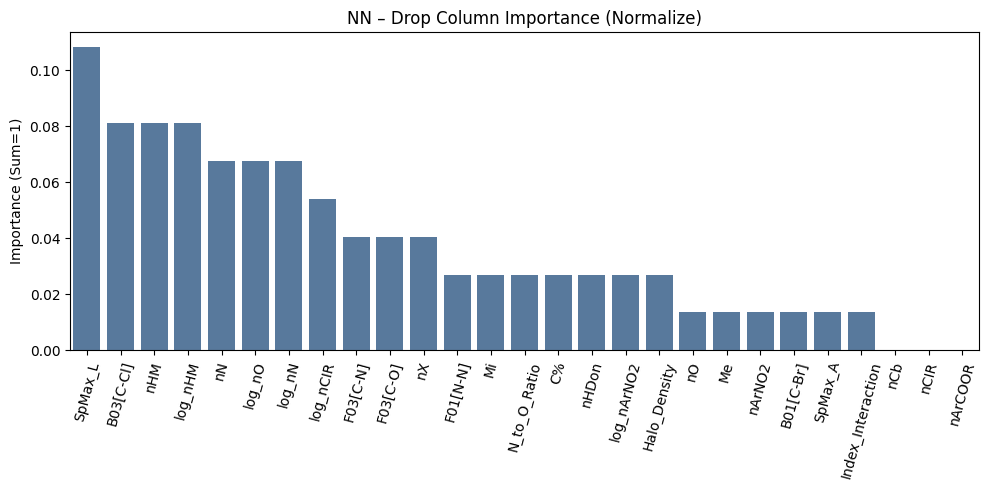

In [86]:

# Alias: tüm özellikler, 2 değer döndürür
dc_raw, dc_norm = drop_column_importance_nn_task1_split()
print("\n[NN – Drop Column] (Unnormalized) Top 10:")
print(pd.Series(dc_raw).sort_values(ascending=False).head(10))
plot_importance_bar(dc_norm, "NN – Drop Column Importance (Normalize)")


In [31]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

In [87]:
class KerasWrapper(BaseEstimator, ClassifierMixin):
    """
    sklearn uyumlu hafif sarmalayıcı:
    - fit: hiçbir şey yapmaz, sadece arayüzü sağlar
    - predict: Keras modelinden olasılık → sınıf (threshold)
    - score: accuracy
    """
    def __init__(self, model, threshold=0.5, n_features_in_=None):
        self.model = model
        self.threshold = threshold
        self._estimator_type = "classifier"
        self.classes_ = np.array([0, 1])
        if n_features_in_ is not None:
            self.n_features_in_ = n_features_in_

    def fit(self, X, y=None):
        # Model zaten fonksiyon içinde eğitiliyor; burada sadece API uyumu sağlıyoruz
        # Sklearn'in parametre doğrulaması bir 'fit' metodunun varlığını kontrol eder.
        return self

    def predict(self, X):
        proba = self.model.predict(_ensure_float32(X), verbose=0).ravel()
        return (proba >= self.threshold).astype(int)

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)


In [88]:

# ============================================================
# Permutation Importance – SciKeras'sız, dayanıklı sürüm
# - Keras modelini kendi builder'ıyla eğitir (Keras 3 uyarısı yok).
# - Hafif bir wrapper ile sklearn.permutation_importance'a verir.
# - top_k ile hızlı ön-seçim destekler.
# ============================================================

def permutation_importance_nn_multi_splits(top_k=None, preselect_method='logreg'):
    # --- Güvenli varsayılanlar (global yoksa devreye girer) ---
    BASE_RANDOM_STATE = globals().get('BASE_RANDOM_STATE', 42)
    N_SPLITS = globals().get('N_SPLITS_PI', 10)           # 10 split
    N_REPEATS = globals().get('N_REPEATS_PI', 10)         # n_repeats=10
    TEST_SIZE = globals().get('TEST_SIZE_FALLBACK',
                  globals().get('FALLBACK_TEST_SIZE', 0.20))

    # --- X,y (Task 1 varsa kullan) ---
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    # --- Hızlı ön-seçim (top_k) – logreg ile (çok hızlı) ---
    features_full = X_all.columns.tolist()
    if isinstance(top_k, int) and top_k > 0:
        X_tr0, X_te0, y_tr0, y_te0 = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=BASE_RANDOM_STATE
        )
        sc0 = StandardScaler().fit(X_tr0)
        X_tr0s = sc0.transform(X_tr0)

        lr0 = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced',
                                 random_state=BASE_RANDOM_STATE)
        lr0.fit(X_tr0s, y_tr0)
        coefs = np.abs(lr0.coef_.ravel())
        order = np.argsort(coefs)[::-1]
        features = X_tr0.columns[order].tolist()[:top_k]
    else:
        features = features_full

    # --- Keras 3 uyarısız sessiz builder ---
    def _build_model_quiet(input_dim, cfg):
        m = keras.Sequential(name=cfg.get('name','NN'))
        m.add(keras.Input(shape=(input_dim,), name="model_input"))  # Keras 3 uyumlu
        for units, dp in zip(cfg['units'], cfg['dropout']):
            m.add(layers.Dense(units, activation=cfg.get('activation','relu')))
            if dp and dp > 0:
                m.add(layers.Dropout(dp))
        m.add(layers.Dense(1, activation='sigmoid'))
        opt = keras.optimizers.Adam(learning_rate=cfg.get('lr', 1e-3))
        m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        return m

    # Task 1'deki cfg'yi al; yoksa kısa fallback
    def _get_cfg():
        try:
            assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
            if 'best3' in globals() and len(best3) > 0:
                return get_cfg_by_name(best3[0])
            return candidates[0]
        except Exception:
            return {
                'name':'NN_fallback_64-32-16',
                'units':[64, 32, 16],
                'dropout':[0.3, 0.3, 0.3],
                'lr':1e-3,
                'activation':'relu',
                'epochs':100,     # kısa varsayılan
                'batch_size':32,
                'patience':5
            }

    def _ensure_float32(Xm):
        if isinstance(Xm, pd.DataFrame):
            return Xm.astype(np.float32)
        return np.asarray(Xm, dtype=np.float32)

    cfg = _get_cfg()
    sum_imp = np.zeros(len(features), dtype=float)
    for s in range(N_SPLITS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all[features], y_all, test_size=TEST_SIZE, stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)

        # Modeli eğit (kısa varsayılanlarla ve EarlyStopping ile)
        es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=min(cfg.get('patience',10), 5),
                                           restore_best_weights=True)
        model = _build_model_quiet(X_tr_s.shape[1], cfg)
        model.fit(_ensure_float32(X_tr_s), y_tr,
                  epochs=min(cfg.get('epochs',100), 100),
                  batch_size=cfg.get('batch_size',32),
                  validation_split=0.2,
                  callbacks=[es], verbose=0)

        # Sarmalayıcı ve permutation importance
        wrapper = KerasWrapper(model, n_features_in_=X_tr_s.shape[1])
        pi = permutation_importance(
            wrapper, _ensure_float32(X_te_s), y_te,
            n_repeats=N_REPEATS,
            random_state=BASE_RANDOM_STATE + s,
            scoring='accuracy'
        )
        sum_imp += np.maximum(0.0, pi.importances_mean)

        tf.keras.backend.clear_session()

    mean_imp = sum_imp / N_SPLITS
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_imp)}

    # normalize
    vals = np.array(list(mean_imp_dict.values()), dtype=float)
    s = vals.sum()
    if s <= 0:
        vals = np.abs(vals); s = vals.sum() if vals.sum() > 0 else 1.0
    vals = vals / s
    mean_imp_norm = {k: float(v) for k, v in zip(mean_imp_dict.keys(), vals)}
    return mean_imp_dict, mean_imp_norm


[NN – Permutation Importance] (Unnormalized) Top 10
SpMax_L    0.057820
nCb        0.023649
log_nHM    0.023507
SpMax_A    0.021659
C%         0.019905
nHM        0.015829
nArCOOR    0.014929
nO         0.013697
log_nN     0.013270
log_nO     0.012796
dtype: float64


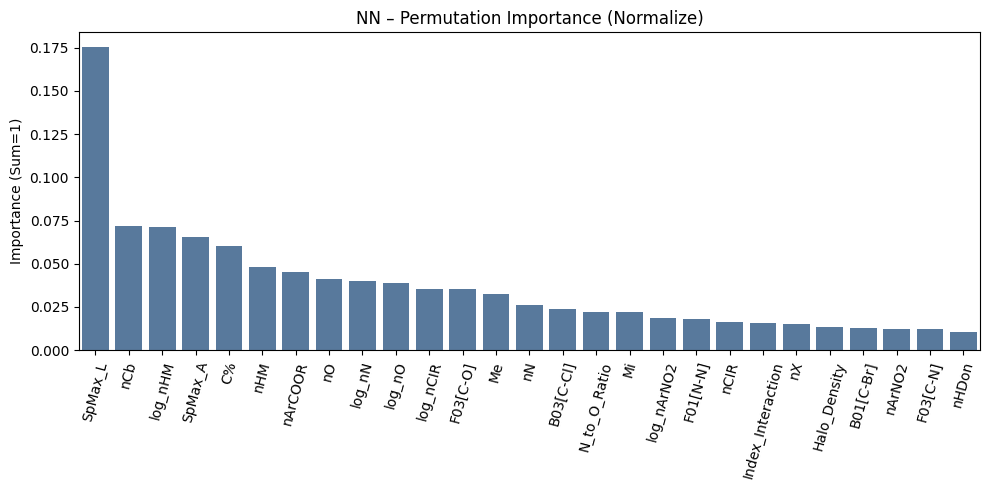

In [89]:
# 2) NN – Permutation Importance (10 split)
pi_raw, pi_norm = permutation_importance_nn_multi_splits()
print("\n[NN – Permutation Importance] (Unnormalized) Top 10")
print(pd.Series(pi_raw).sort_values(ascending=False).head(10))
plot_importance_bar(pi_norm, "NN – Permutation Importance (Normalize)")

In [90]:
from sklearn.linear_model import LogisticRegression

In [91]:
# --- 3) Logistic Regression – 10 farklı split ---
def logistic_regression_importance_multi_splits():
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    features = X_all.columns.tolist()
    sum_abs = np.zeros(len(features), dtype=float)

    for s in range(N_SPLITS_PI):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=TEST_SIZE_FALLBACK,
            stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)

        lr = LogisticRegression(
            max_iter=2000, solver='liblinear',
            class_weight='balanced',
            random_state=BASE_RANDOM_STATE + s
        )
        lr.fit(X_tr_s, y_tr)
        coefs = lr.coef_.ravel()
        sum_abs += np.abs(coefs)

    mean_abs = sum_abs / N_SPLITS_PI
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_abs)}
    mean_imp_norm = normalize_importances(mean_imp_dict)
    return mean_imp_dict, mean_imp_norm


[Logistic Regression] |coef| ort. (Unnormalized) Top 10
nX          1.509850
nCb         1.464450
C%          1.134994
log_nN      1.025258
SpMax_L     0.804327
log_nO      0.697410
F03[C-O]    0.680076
nHM         0.658133
nN          0.522749
nArCOOR     0.511577
dtype: float64


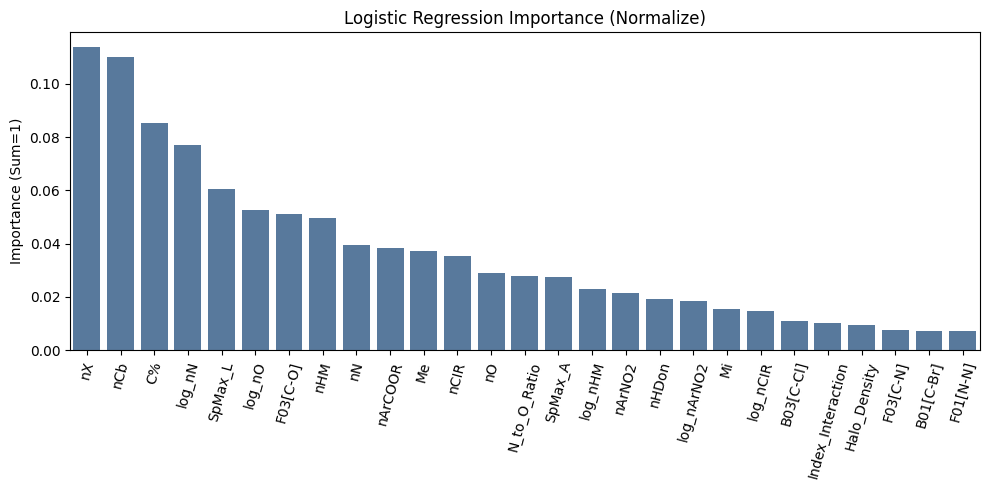

In [92]:
# 3) Logistic Regression (10 split)
lr_raw, lr_norm = logistic_regression_importance_multi_splits()
print("\n[Logistic Regression] |coef| ort. (Unnormalized) Top 10")
print(pd.Series(lr_raw).sort_values(ascending=False).head(10))
plot_importance_bar(lr_norm, "Logistic Regression Importance (Normalize)")

In [2]:
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [93]:

# --- 4) CatBoost – 10 farklı split (Varyantın: 3 → Classification Q4 = CatBoost) ---
def catboost_importance_multi_splits():
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    features = X_all.columns.tolist()
    sum_imp = np.zeros(len(features), dtype=float)

    for s in range(N_SPLITS_PI):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=TEST_SIZE_FALLBACK,
            stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        train_pool = Pool(X_tr, y_tr)
        valid_pool = Pool(X_te, y_te)

        cat = CatBoostClassifier(
            iterations=400, learning_rate=0.05, depth=6,
            loss_function='Logloss', eval_metric='Accuracy',
            random_state=BASE_RANDOM_STATE + s,
            verbose=False
        )
        cat.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50, verbose=False)
        imp = np.array(cat.get_feature_importance(train_pool), dtype=float)
        sum_imp += np.maximum(0.0, imp)

    mean_imp = sum_imp / N_SPLITS_PI
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_imp)}
    mean_imp_norm = normalize_importances(mean_imp_dict)
    return mean_imp_dict, mean_imp_norm


[CatBoost] established importance (Unnormalized) Top 10
SpMax_L         16.545214
SpMax_A         11.500135
nHM              7.647842
log_nHM          6.589141
nN               6.158264
log_nO           5.137051
nO               4.856665
nCb              4.807117
N_to_O_Ratio     4.185938
log_nN           4.088560
dtype: float64


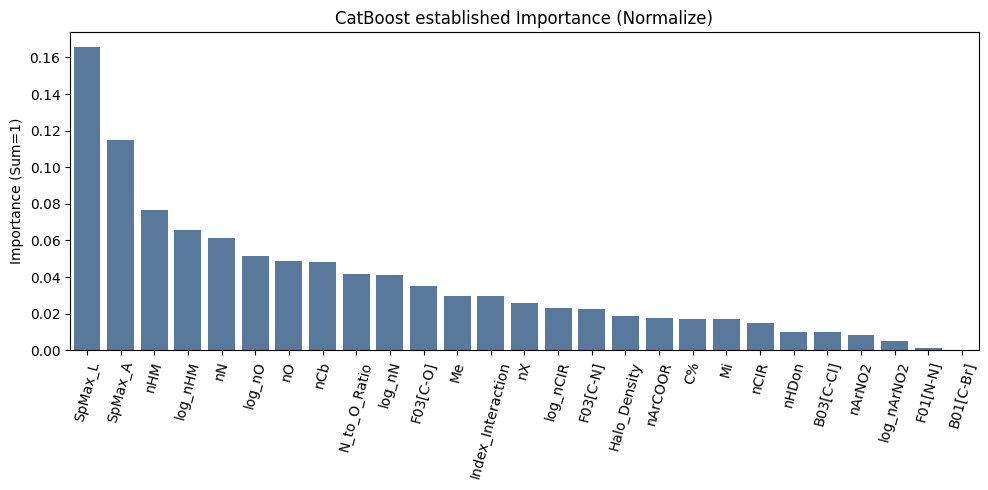

In [94]:
# 4) CatBoost (10 split) – (Varyantına uygun olarak Q4: CatBoost)
cb_raw, cb_norm = catboost_importance_multi_splits()
print("\n[CatBoost] established importance (Unnormalized) Top 10")
print(pd.Series(cb_raw).sort_values(ascending=False).head(10))
plot_importance_bar(cb_norm, "CatBoost established Importance (Normalize)")

In [95]:
print("The existence of defaults:")
for name in ['X','y','X_train','X_test','y_train','y_test','scaler',
             'candidates','get_cfg_by_name','best3',
             'build_model','build_keras_sequential']:
    print(f" - {name}: {'OK' if name in globals() else 'MISSING'}")

if 'X' in globals():
    print("\nX shape & dtypes:", X.shape, "\n", X.dtypes.head())
if 'X_train' in globals():
    print("\nX_train shape:", X_train.shape)
if 'scaler' in globals():
    try:
        # Eğer scaler, DataFrame ile fit edildiyse feature names mevcuttur
        print("\nScaler fitted attrs:", hasattr(scaler, 'mean_'), hasattr(scaler, 'n_features_in_'))
    except Exception as e:
        print("Scaler introspection error:", e)

The existence of defaults:
 - X: OK
 - y: OK
 - X_train: OK
 - X_test: OK
 - y_train: OK
 - y_test: OK
 - scaler: OK
 - candidates: OK
 - get_cfg_by_name: OK
 - best3: OK
 - build_model: OK
 - build_keras_sequential: OK

X shape & dtypes: (1055, 27) 
 SpMax_L     float64
nHM           int64
F01[N-N]      int64
nCb           int64
C%          float64
dtype: object

X_train shape: (844, 27)

Scaler fitted attrs: True True


In [37]:

# Eğer build_keras_sequential tanımlı değilse, build_model'i alias yap
if 'build_keras_sequential' not in globals() and 'build_model' in globals():
    def build_keras_sequential(input_dim, cfg):
        # Var olan build_model fonksiyonunu kullan
        return build_model(input_dim, cfg)

print("Alias kontrolü tamamlandı:",
      "build_model:", 'OK' if 'build_model' in globals() else 'MISSING',
      "| build_keras_sequential:", 'OK' if 'build_keras_sequential' in globals() else 'MISSING')


Alias kontrolü tamamlandı: build_model: OK | build_keras_sequential: OK


In [96]:
if 'X' in globals():
    features_all = X.columns.tolist()
else:
    features_all = list(dc_norm.keys())  # güvenli fallback

comp_df = pd.DataFrame({
    'Feature': features_all,
    'NN_DropColumn': [dc_norm.get(f, 0.0) for f in features_all],
    'NN_Permutation': [pi_norm.get(f, 0.0) for f in features_all],
    'LogReg': [lr_norm.get(f, 0.0) for f in features_all],
    'CatBoost': [cb_norm.get(f, 0.0) for f in features_all],
})

In [97]:
# Ortalama önem (yöntemlerin aritmetik ortalaması)
comp_df['Mean_All'] = comp_df[['NN_DropColumn','NN_Permutation','LogReg','CatBoost']].mean(axis=1)

In [98]:
comp_df['Mean_All']

,Mean_All
0,0.127291
1,0.063756
2,0.013315
3,0.057476
4,0.047500
5,0.033096
6,0.020712
7,0.040474
8,0.028255
9,0.020506


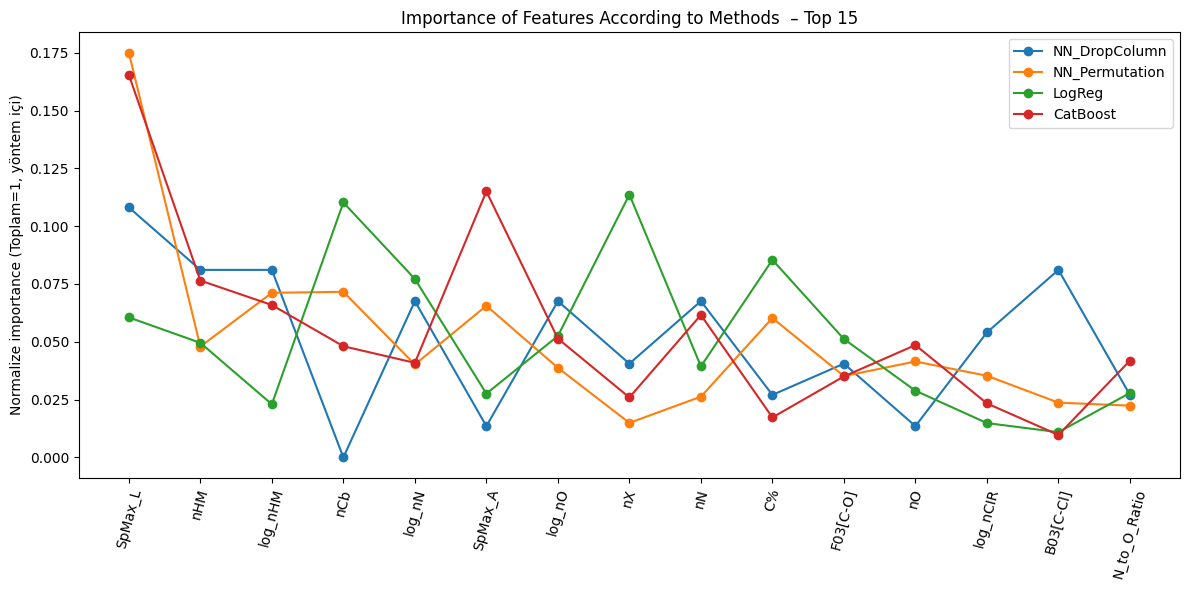

In [99]:

# En önemli 15 özelliği tek grafikte
topN = 15
top_df = comp_df.sort_values('Mean_All', ascending=False).head(topN)
plt.figure(figsize=(12,6))
for col in ['NN_DropColumn','NN_Permutation','LogReg','CatBoost']:
    plt.plot(top_df['Feature'], top_df[col], marker='o', label=col)
plt.xticks(rotation=75)
plt.ylabel('Normalize importance (Toplam=1, yöntem içi)')
plt.title('Importance of Features According to Methods  – Top 15')
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
comp_df.to_csv('task2_feature_importances_all_methods.csv', index=False)

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from lime.lime_tabular import LimeTabularExplainer

In [103]:
if 'BASE_RANDOM_STATE' not in globals(): BASE_RANDOM_STATE = 42
if 'TEST_SIZE'         not in globals(): TEST_SIZE = 0.20   # Assignment 2 oranınızı burada kullanın
if 'FALLBACK_TEST_SIZE' not in globals(): FALLBACK_TEST_SIZE = TEST_SIZE
if 'DEFAULT_EPOCHS'    not in globals(): DEFAULT_EPOCHS = 100
if 'DEFAULT_PATIENCE'  not in globals(): DEFAULT_PATIENCE = 5

In [104]:
# ---- Task 1'deki build fonksiyonu yoksa Input(shape=...) ile uyarısız builder tanımlayalım ----
def _build_model_quiet(input_dim, cfg):
    """A Keras 3 compatible builder that uses Input(shape=...) in the first layer."""
    m = keras.Sequential(name=cfg.get('name','NN'))
    m.add(keras.Input(shape=(input_dim,), name="model_input"))
    for units, dp in zip(cfg['units'], cfg['dropout']):
        m.add(layers.Dense(units, activation=cfg.get('activation','relu')))
        if dp and dp > 0:
            m.add(layers.Dropout(dp))
    m.add(layers.Dense(1, activation='sigmoid'))
    opt = keras.optimizers.Adam(learning_rate=cfg.get('lr', 1e-3))
    m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [105]:
# Eğer build_keras_sequential yoksa, var olan build_model'i alias'layalım;
# ikisi de yoksa _build_model_quiet'i kullanırız.
if 'build_keras_sequential' not in globals():
    if 'build_model' in globals():
        def build_keras_sequential(input_dim, cfg):
            return build_model(input_dim, cfg)
    else:
        def build_keras_sequential(input_dim, cfg):
            return _build_model_quiet(input_dim, cfg)

In [106]:
# Task 1'deki en iyi konfigürasyonu çek; yoksa kısa fallback
def _get_best_cfg():
    try:
        assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
        if 'best3' in globals() and len(best3) > 0:
            cfg = get_cfg_by_name(best3[0])
        else:
            cfg = candidates[0]
    except Exception:
        cfg = {
            'name':'NN_fallback_64-32-16',
            'units':[64, 32, 16],
            'dropout':[0.3, 0.3, 0.3],
            'lr':1e-3, 'activation':'relu',
            'epochs':DEFAULT_EPOCHS, 'batch_size':32, 'patience':DEFAULT_PATIENCE
        }
    # Kısa varsayılanlara zorla (hız için)
    cfg = dict(cfg)
    cfg['epochs']   = min(cfg.get('epochs',100), DEFAULT_EPOCHS)
    cfg['patience'] = min(cfg.get('patience',10), DEFAULT_PATIENCE)
    return cfg

In [107]:
def _ensure_float32(X):
    if isinstance(X, pd.DataFrame):
        return X.astype(np.float32)
    return np.asarray(X, dtype=np.float32)

In [109]:

# Task 1 verileri yoksa minimum bootstrap
def _get_data_task1_or_bootstrap():
    if 'X' in globals() and 'y' in globals():
        local_X, local_y = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        local_y = df_fb['Class'].map({'RB':1,'NRB':0}).astype(int)
        local_X = df_fb.drop(columns=['Class'])

    if all(v in globals() for v in ['X_train','X_test','y_train','y_test','scaler']):
        X_tr, X_te = X_train.copy(), X_test.copy()
        y_tr, y_te = y_train.copy(), y_test.copy()
        sc = scaler
        # scaled'lar varsa onları da kullan
        X_train_scaled_used = globals().get('X_train_scaled', sc.transform(X_tr))
        X_test_scaled_used  = globals().get('X_test_scaled',  sc.transform(X_te))
    else:
        X_tr, X_te, y_tr, y_te = train_test_split(
            local_X, local_y, test_size=FALLBACK_TEST_SIZE,
            stratify=local_y, random_state=BASE_RANDOM_STATE
        )
        sc = StandardScaler().fit(X_tr)
        X_train_scaled_used = sc.transform(X_tr)
        X_test_scaled_used  = sc.transform(X_te)

    # DataFrame olarak paketleyelim (özellik adları için)
    X_train_scaled_df = pd.DataFrame(X_train_scaled_used, columns=X_tr.columns, index=X_tr.index)
    X_test_scaled_df  = pd.DataFrame(X_test_scaled_used,  columns=X_te.columns, index=X_te.index)
    return local_X, local_y, X_tr, X_te, y_tr, y_te, sc, X_train_scaled_df, X_test_scaled_df


In [110]:
print("LIME – The first condition cell is ready.")

LIME – The first condition cell is ready.


In [111]:
# ==== Bölüm A: Tek-split (Task 1) LIME açıklamaları (gözlem 4 ve 5) ====

# 0) Veriyi ve en iyi konfigi al
X_all, y_all, X_tr, X_te, y_tr, y_te, sc, X_tr_s, X_te_s = _get_data_task1_or_bootstrap()
cfg = _get_best_cfg()
feature_names = X_tr.columns.tolist()
class_names   = ['NRB','RB']

In [112]:
# 1) Modeli eğit (Task 1 split)
tf.keras.backend.clear_session()
model = build_keras_sequential(X_tr_s.shape[1], cfg)
es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                   patience=cfg.get('patience',5),
                                   restore_best_weights=True)
history = model.fit(
    _ensure_float32(X_tr_s), y_tr,
    epochs=cfg.get('epochs',100), batch_size=cfg.get('batch_size',32),
    validation_split=0.2, callbacks=[es], verbose=0
)

In [113]:
# 2) LIME explainer (scaled training verisi ile)
explainer = LimeTabularExplainer(
    training_data=_ensure_float32(X_tr_s.values),
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True # yerel doğrusal açıklamalarda yaygın tercih
)

In [114]:
# 3) LIME'in beklediği predict_proba: Nx2 (NRB, RB)
def predict_proba_fn(X_scaled_nd):
    p1 = model.predict(_ensure_float32(X_scaled_nd), verbose=0).ravel()        # RB olasılığı
    p0 = 1.0 - p1                                                               # NRB
    return np.vstack([p0, p1]).T

In [115]:
# 4) Gözlem indexleri (test set içinde 0-bazlı 3 ve 4 → "4. ve 5. gözlem")
test_positions = [3, 4]  # gerekirse değiştir: Assignment tablosu 4,5 diyor

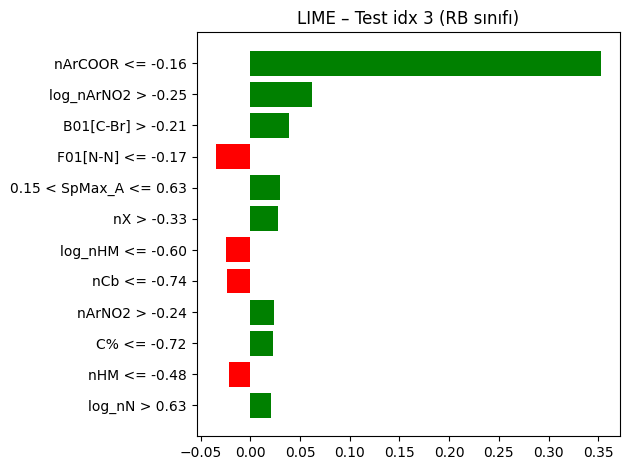

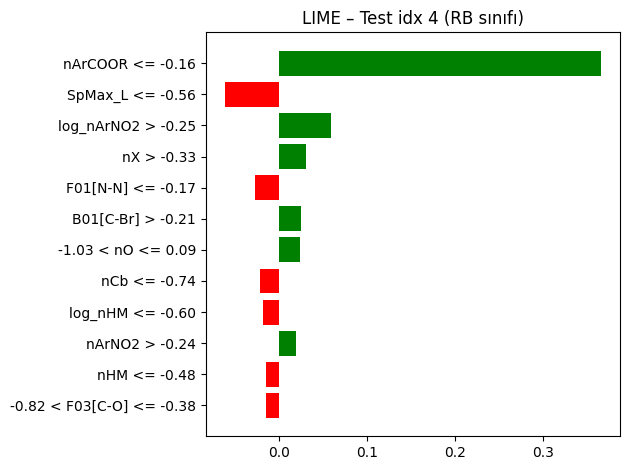

In [117]:
# 5) Her gözlem için açıklama ve çizim
instance_explanations = {}
for pos in test_positions:
    x0 = X_te_s.iloc[pos:pos+1, :]             # 1xD (scaled)
    exp = explainer.explain_instance(
        data_row=x0.values[0],
        predict_fn=predict_proba_fn,
        num_features=min(12, X_tr_s.shape[1]), # grafikte en çok 12 özellik
        top_labels=len(class_names)           # Ensure explanations for all classes are generated
    )
    instance_explanations[pos] = exp

    # LIME'ın hazır figürü
    fig = exp.as_pyplot_figure(label=1)  # RB sınıfı için bar plot
    plt.title(f"LIME – Test idx {pos} (RB sınıfı)")
    plt.tight_layout()
    plt.show()

In [118]:
# 6) (İsteğe bağlı) açıklama çiftlerini tabloya döküp yazdır
def exp_to_series(exp, label=1):
    # LIME explanation: list of (feature_string, weight)
    items = exp.as_list(label=label)
    # negatif/pozitif ağırlıkları göstermek için olduğu gibi alıyoruz
    return pd.Series({k: v for k, v in items})

In [119]:
for pos, exp in instance_explanations.items():
    print(f"\n>>> Test idx {pos} – LIME RB contributions (signed weights):")
    s = exp_to_series(exp, label=1)
    print(s.sort_values(key=lambda x: np.abs(x), ascending=False).head(12))


>>> Test idx 3 – LIME RB contributions (signed weights):
nArCOOR <= -0.16          0.352521
log_nArNO2 > -0.25        0.062235
B01[C-Br] > -0.21         0.039249
F01[N-N] <= -0.17        -0.034779
0.15 < SpMax_A <= 0.63    0.029600
nX > -0.33                0.027414
log_nHM <= -0.60         -0.024779
nCb <= -0.74             -0.023749
nArNO2 > -0.24            0.023250
C% <= -0.72               0.022591
nHM <= -0.48             -0.021387
log_nN > 0.63             0.021206
dtype: float64

>>> Test idx 4 – LIME RB contributions (signed weights):
nArCOOR <= -0.16             0.366307
SpMax_L <= -0.56            -0.062459
log_nArNO2 > -0.25           0.059264
nX > -0.33                   0.030233
F01[N-N] <= -0.17           -0.027583
B01[C-Br] > -0.21            0.024110
-1.03 < nO <= 0.09           0.023766
nCb <= -0.74                -0.021662
log_nHM <= -0.60            -0.019154
nArNO2 > -0.24               0.019084
nHM <= -0.48                -0.015539
-0.82 < F03[C-O] <= -0.38   -0.

In [ ]:

# 2) LIME explainer (scaled training verisi ile) – aynı
explainer = LimeTabularExplainer(
    training_data=_ensure_float32(X_tr_s.values),
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True
)

def predict_proba_fn(X_scaled_nd):
    p1 = model.predict(_ensure_float32(X_scaled_nd), verbose=0).ravel()  # RB
    p0 = 1.0 - p1                                                        # NRB
    return np.vstack([p0, p1]).T

test_positions = [3, 4]
instance_explanations = {}
for pos in test_positions:
    x0 = X_te_s.iloc[pos:pos+1, :]
    exp = explainer.explain_instance(
        data_row=x0.values[0],
        predict_fn=predict_proba_fn,
        num_features=min(12, X_tr_s.shape[1]),
        top_labels=2      # <-- RB yoksa en azından NRB'yi de kaydetsin
    )
    # RB (1) varsa onu; yoksa mevcut ilk etiketi kullan
    label_for_plot = 1 if 1 in exp.available_labels else exp.available_labels[0]
    instance_explanations[pos] = (exp, label_for_plot)

    fig = exp.as_pyplot_figure(label=label_for_plot)
    plt.title(f"LIME – Test idx {pos} (label={class_names[label_for_plot]})")
    plt.tight_layout()
    plt.show()

def exp_to_series(exp, label):
    items = exp.as_list(label=label)
    return pd.Series({k: v for k, v in items})

for pos, (exp, lab) in instance_explanations.items():
    print(f"\n>>> Test idx {pos} – LIME katkıları (label={class_names[lab]}):")
    s = exp_to_series(exp, label=lab)
    print(s.sort_values(key=lambda x: np.abs(x), ascending=False).head(12))

In [ ]:

N_SPLITS_LIME = 10          # hız için 5 de olur
TEST_SIZE_LIME = TEST_SIZE  # Assignment 2 oranınız

def lime_average_over_splits(test_positions=[3,4], num_features_bar=12):
    """
    In each split, it describes the positions [3,4] in the test set,
    sums and averages the contributions as |weights| (by aligning the feature names).
    """
    avg_dict_pos = {pos: None for pos in test_positions}

    for s in range(N_SPLITS_LIME):
        # Split & scale
        if 'X' in globals() and 'y' in globals():
            X_all_s, y_all_s = X.copy(), y.copy()
        else:
            df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
            y_all_s = df_fb['Class'].map({'RB':1,'NRB':0}).astype(int)
            X_all_s = df_fb.drop(columns=['Class'])

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all_s, y_all_s, test_size=TEST_SIZE_LIME,
            stratify=y_all_s, random_state=BASE_RANDOM_STATE + s
        )
        sc = StandardScaler().fit(X_tr)
        X_tr_s = pd.DataFrame(sc.transform(X_tr), columns=X_tr.columns, index=X_tr.index)
        X_te_s  = pd.DataFrame(sc.transform(X_te), columns=X_te.columns, index=X_te.index)

        # Model (kısa varsayılanlar)
        cfg = _get_best_cfg()
        tf.keras.backend.clear_session()
        model = build_keras_sequential(X_tr_s.shape[1], cfg)
        es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=cfg.get('patience',5),
                                           restore_best_weights=True)
        model.fit(
            _ensure_float32(X_tr_s), y_tr,
            epochs=cfg.get('epochs',100), batch_size=cfg.get('batch_size',32),
            validation_split=0.2, callbacks=[es], verbose=0
        )

        explainer = LimeTabularExplainer(
            training_data=_ensure_float32(X_tr_s.values),
            feature_names=X_tr.columns.tolist(),
            class_names=['NRB','RB'],
            mode='classification',
            discretize_continuous=True
        )
        def predict_proba_fn(X_scaled_nd):
            p1 = model.predict(_ensure_float32(X_scaled_nd), verbose=0).ravel()
            p0 = 1.0 - p1
            return np.vstack([p0, p1]).T

        for pos in test_positions:
            if pos >= len(X_te_s):
                continue
            x0 = X_te_s.iloc[pos:pos+1, :]
            exp = explainer.explain_instance(
                data_row=x0.values[0],
                predict_fn=predict_proba_fn,
                num_features=min(20, X_tr_s.shape[1]),
                top_labels=2   # <-- iki sınıfı da al
            )
            # RB varsa RB; yoksa mevcut ilk etiket
            label_for_avg = 1 if 1 in exp.available_labels else exp.available_labels[0]
            items = exp.as_list(label=label_for_avg)
            if not items:
                continue
            s_abs = pd.Series({k: abs(v) for k, v in items})

            if avg_dict_pos[pos] is None:
                avg_dict_pos[pos] = s_abs
            else:
                avg_dict_pos[pos] = avg_dict_pos[pos].add(s_abs, fill_value=0.0)

        tf.keras.backend.clear_session()

    # Ortalama ve grafik
    avg_results = {}
    for pos in test_positions:
        if avg_dict_pos[pos] is None:
            print(f"[Uyarı] Split'lerin hiçbirinde test pozisyonu {pos} için geçerli LIME çıktısı oluşmadı.")
            continue
        avg_s = (avg_dict_pos[pos] / N_SPLITS_LIME).sort_values(ascending=False)

        top = avg_s.head(num_features_bar)
        plt.figure(figsize=(8,4))
        sns.barplot(x=top.values, y=top.index, color="#4c78a8")
        plt.title(f"LIME Ortalama |katkı| – Test pozisyon {pos} (N={N_SPLITS_LIME} split)")
        plt.xlabel("Ortalama |LIME ağırlığı|")
        plt.ylabel("Özellik (LIME kuralı)")
        plt.tight_layout()
        plt.show()

        avg_results[pos] = avg_s

        top = avg_s.sort_values(ascending=False).head(num_features_bar)

        plt.figure(figsize=(8,4))
        sns.barplot(x=top.values, y=top.index, color="#4c78a8")
        plt.title(f"LIME Average |contribution| – Test position {pos} (N={N_SPLITS_LIME} split)")
        plt.xlabel("Average |LIME weight|")
        plt.ylabel("Property (LIME rule)")
        plt.tight_layout()
        plt.show()

    return avg_results


In [120]:

# ==== Bölüm B: 10 farklı split ile LIME ortalaması (gözlem 4 ve 5) ====

N_SPLITS_LIME = 5    # hız istersen 5 de olur
TEST_SIZE_LIME = TEST_SIZE  # Assignment 2 oranı ile aynı tut

def lime_average_over_splits(test_positions=[3,4], num_features_bar=12):
    """
    In each split, it describes the positions [3,4] in the test set,
    sums and averages the contributions as |weights| (by aligning the feature names).
    """
    avg_dict_pos = {pos: None for pos in test_positions}

    for s in range(N_SPLITS_LIME):
        # Split & scale
        if 'X' in globals() and 'y' in globals():
            X_all_s, y_all_s = X.copy(), y.copy()
        else:
            df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
            y_all_s = df_fb['Class'].map({'RB':1,'NRB':0}).astype(int)
            X_all_s = df_fb.drop(columns=['Class'])

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all_s, y_all_s, test_size=TEST_SIZE_LIME,
            stratify=y_all_s, random_state=BASE_RANDOM_STATE + s
        )
        sc = StandardScaler().fit(X_tr)
        X_tr_s = pd.DataFrame(sc.transform(X_tr), columns=X_tr.columns, index=X_tr.index)
        X_te_s  = pd.DataFrame(sc.transform(X_te), columns=X_te.columns, index=X_te.index)

        # Model
        cfg = _get_best_cfg()
        tf.keras.backend.clear_session()
        model = build_keras_sequential(X_tr_s.shape[1], cfg)
        es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=cfg.get('patience',5),
                                           restore_best_weights=True)
        model.fit(
            _ensure_float32(X_tr_s), y_tr,
            epochs=cfg.get('epochs',100), batch_size=cfg.get('batch_size',32),
            validation_split=0.2, callbacks=[es], verbose=0
        )

        # LIME explainer & predict_fn
        explainer = LimeTabularExplainer(
            training_data=_ensure_float32(X_tr_s.values),
            feature_names=X_tr.columns.tolist(),
            class_names=['NRB','RB'],
            mode='classification',
            discretize_continuous=True
        )
        def predict_proba_fn(X_scaled_nd):
            p1 = model.predict(_ensure_float32(X_scaled_nd), verbose=0).ravel()
            p0 = 1.0 - p1
            return np.vstack([p0, p1]).T

        # Her hedef pozisyon için açıklama → |weight| serisi
        for pos in test_positions:
            # Eğer split'teki test boyutu 5'ten küçükse pos aşımı olmasın:
            if pos >= len(X_te_s):
                continue
            x0 = X_te_s.iloc[pos:pos+1, :]
            exp = explainer.explain_instance(
                data_row=x0.values[0],
                predict_fn=predict_proba_fn,
                num_features=min(20, X_tr_s.shape[1]),
                top_labels=1
            )
            items = exp.as_list(label=1)
            s_abs = pd.Series({k: abs(v) for k, v in items})
            # Özellik adlarını normalize etmek (LIME, kural cümleleri döndürebilir)
            # En güvenlisi: kural cümlelerini aynen tutuyoruz; ortalamayı aynı anahtarlarla yapıyoruz.
            if avg_dict_pos[pos] is None:
                avg_dict_pos[pos] = s_abs
            else:
                avg_dict_pos[pos] = avg_dict_pos[pos].add(s_abs, fill_value=0.0)

        tf.keras.backend.clear_session()

    # Ortalama ve grafik
    avg_results = {}
    for pos in test_positions:
        if avg_dict_pos[pos] is None:
            continue
        avg_s = (avg_dict_pos[pos] / N_SPLITS_LIME)
        # En güçlü num_features_bar katkıyı görselleştir
        top = avg_s.sort_values(ascending=False).head(num_features_bar)

        plt.figure(figsize=(8,4))
        sns.barplot(x=top.values, y=top.index, color="#4c78a8")
        plt.title(f"LIME Average |contribution| – Test position {pos} (N={N_SPLITS_LIME} split)")
        plt.xlabel("Average |LIME weight|")
        plt.ylabel("Property (LIME rule)")
        plt.tight_layout()
        plt.show()

        avg_results[pos] = avg_s

    return avg_results

In [121]:
avg_lime = lime_average_over_splits(test_positions=[3,4], num_features_bar=12)

KeyError: 1